In [1]:
import pandas as pd

df = pd.read_parquet(
    "Embeddings/DL/Texto/train.parquet"
)

print(df.columns.tolist())

['patch_id', 'dim_000', 'dim_001', 'dim_002', 'dim_003', 'dim_004', 'dim_005', 'dim_006', 'dim_007', 'dim_008', 'dim_009', 'dim_010', 'dim_011', 'dim_012', 'dim_013', 'dim_014', 'dim_015', 'dim_016', 'dim_017', 'dim_018', 'dim_019', 'dim_020', 'dim_021', 'dim_022', 'dim_023', 'dim_024', 'dim_025', 'dim_026', 'dim_027', 'dim_028', 'dim_029', 'dim_030', 'dim_031', 'dim_032', 'dim_033', 'dim_034', 'dim_035', 'dim_036', 'dim_037', 'dim_038', 'dim_039', 'dim_040', 'dim_041', 'dim_042', 'dim_043', 'dim_044', 'dim_045', 'dim_046', 'dim_047', 'dim_048', 'dim_049', 'dim_050', 'dim_051', 'dim_052', 'dim_053', 'dim_054', 'dim_055', 'dim_056', 'dim_057', 'dim_058', 'dim_059', 'dim_060', 'dim_061', 'dim_062', 'dim_063', 'dim_064', 'dim_065', 'dim_066', 'dim_067', 'dim_068', 'dim_069', 'dim_070', 'dim_071', 'dim_072', 'dim_073', 'dim_074', 'dim_075', 'dim_076', 'dim_077', 'dim_078', 'dim_079', 'dim_080', 'dim_081', 'dim_082', 'dim_083', 'dim_084', 'dim_085', 'dim_086', 'dim_087', 'dim_088', 'dim_089

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np


# ============================================================
# 1. CONFIGURAÇÃO
# ============================================================

BASE_DIR = Path(
    "/home/ettore/Documentos/PUC/Projeto_Deep_Learning"
)

EMBEDDINGS_DIR = BASE_DIR / "Embeddings"


# ============================================================
# 2. COLUNAS DOS EMBEDDINGS
# ============================================================

DIM_COLS = [
    f"dim_{i:03d}"
    for i in range(128)
]

print(DIM_COLS[:3])
print(DIM_COLS[-3:])


# ============================================================
# 3. FUNÇÃO PARA CARREGAR E JUNTAR OS SPLITS
# ============================================================

def carregar_embeddings(caminho_subpasta):

    splits = ["train", "validation", "test"]

    dataframes = []

    for split in splits:

        caminho = caminho_subpasta / f"{split}.parquet"

        if not caminho.exists():
            raise FileNotFoundError(
                f"Arquivo não encontrado: {caminho}"
            )

        df = pd.read_parquet(caminho)

        # Verificar se todas as colunas existem
        colunas_esperadas = ["patch_id"] + DIM_COLS

        colunas_faltantes = [
            col
            for col in colunas_esperadas
            if col not in df.columns
        ]

        if colunas_faltantes:
            raise ValueError(
                f"Colunas ausentes em {caminho}: "
                f"{colunas_faltantes}"
            )

        # Selecionar somente ID + embedding
        df = df[colunas_esperadas].copy()

        # Registrar split
        df["split"] = split

        dataframes.append(df)

        print(
            f"{split}: {df.shape}"
        )

    # Juntar train + validation + test
    embeddings = pd.concat(
        dataframes,
        ignore_index=True
    )

    print(
        f"Total {caminho_subpasta}: "
        f"{embeddings.shape}"
    )

    return embeddings


# ============================================================
# 4. CARREGAR OS QUATRO EMBEDDINGS
# ============================================================

Tradicional_Texto = carregar_embeddings(
    EMBEDDINGS_DIR / "Not_CNN" / "Texto"
)

Tradicional_Imagem = carregar_embeddings(
    EMBEDDINGS_DIR / "Not_CNN" / "Imagem"
)

DL_Texto = carregar_embeddings(
    EMBEDDINGS_DIR / "DL" / "Texto"
)

DL_Imagem = carregar_embeddings(
    EMBEDDINGS_DIR / "DL" / "Imagem"
)


# ============================================================
# 5. EXTRAIR SOMENTE OS VETORES NUMÉRICOS
# ============================================================

X_Tradicional_Texto = (
    Tradicional_Texto[DIM_COLS]
    .to_numpy(dtype=np.float32)
)

X_Tradicional_Imagem = (
    Tradicional_Imagem[DIM_COLS]
    .to_numpy(dtype=np.float32)
)

X_DL_Texto = (
    DL_Texto[DIM_COLS]
    .to_numpy(dtype=np.float32)
)

X_DL_Imagem = (
    DL_Imagem[DIM_COLS]
    .to_numpy(dtype=np.float32)
)


# ============================================================
# 6. VERIFICAR RESULTADOS
# ============================================================

print("\n" + "=" * 60)
print("DATAFRAMES COMPLETOS")
print("=" * 60)

print("Tradicional_Texto:", Tradicional_Texto.shape)
print("Tradicional_Imagem:", Tradicional_Imagem.shape)
print("DL_Texto:", DL_Texto.shape)
print("DL_Imagem:", DL_Imagem.shape)


print("\n" + "=" * 60)
print("MATRIZES DE EMBEDDINGS")
print("=" * 60)

print("X_Tradicional_Texto:", X_Tradicional_Texto.shape)
print("X_Tradicional_Imagem:", X_Tradicional_Imagem.shape)
print("X_DL_Texto:", X_DL_Texto.shape)
print("X_DL_Imagem:", X_DL_Imagem.shape)

['dim_000', 'dim_001', 'dim_002']
['dim_125', 'dim_126', 'dim_127']
train: (20996, 130)
validation: (4500, 130)
test: (4504, 130)
Total /home/ettore/Documentos/PUC/Projeto_Deep_Learning/Embeddings/Not_CNN/Texto: (30000, 130)
train: (20996, 130)
validation: (4500, 130)
test: (4504, 130)
Total /home/ettore/Documentos/PUC/Projeto_Deep_Learning/Embeddings/Not_CNN/Imagem: (30000, 130)
train: (20996, 130)
validation: (4500, 130)
test: (4504, 130)
Total /home/ettore/Documentos/PUC/Projeto_Deep_Learning/Embeddings/DL/Texto: (30000, 130)
train: (20996, 130)
validation: (4500, 130)
test: (4504, 130)
Total /home/ettore/Documentos/PUC/Projeto_Deep_Learning/Embeddings/DL/Imagem: (30000, 130)

DATAFRAMES COMPLETOS
Tradicional_Texto: (30000, 130)
Tradicional_Imagem: (30000, 130)
DL_Texto: (30000, 130)
DL_Imagem: (30000, 130)

MATRIZES DE EMBEDDINGS
X_Tradicional_Texto: (30000, 128)
X_Tradicional_Imagem: (30000, 128)
X_DL_Texto: (30000, 128)
X_DL_Imagem: (30000, 128)


Texto Tradicional: (30000, 128)
Texto DL: (30000, 128)
Imagem Tradicional: (30000, 128)
Imagem DL: (30000, 128)


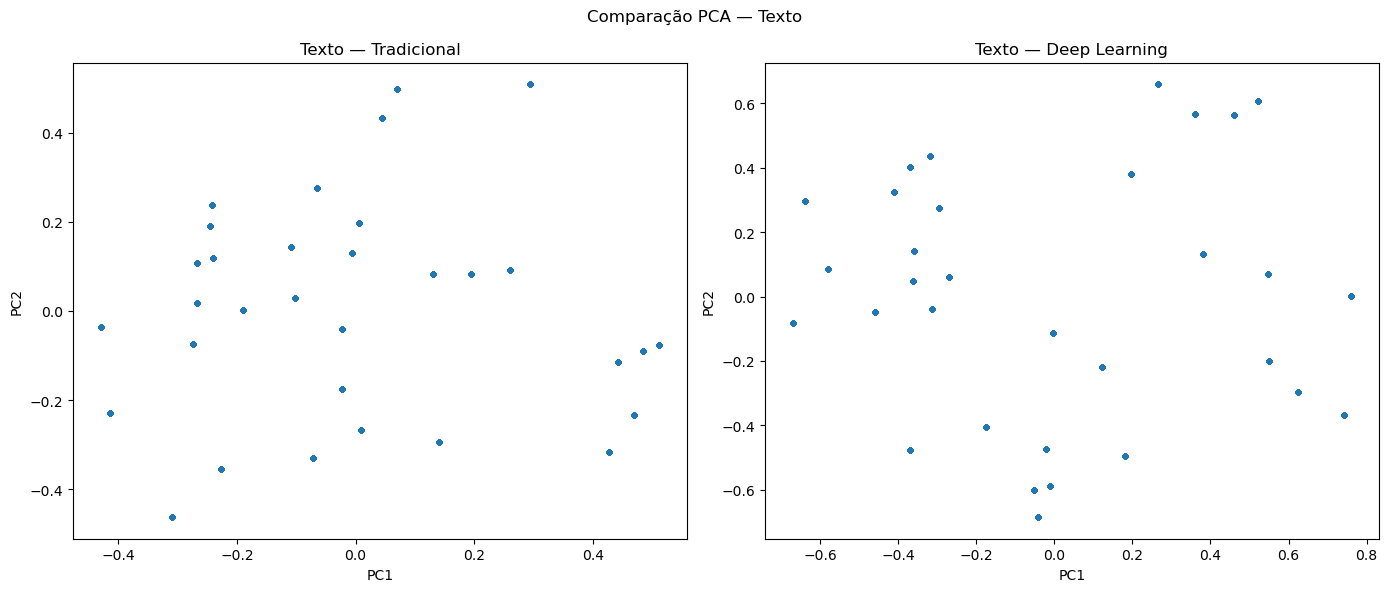


Texto
Variância explicada PCA tradicional: 0.15624553
Variância explicada PCA DL: 0.31989184


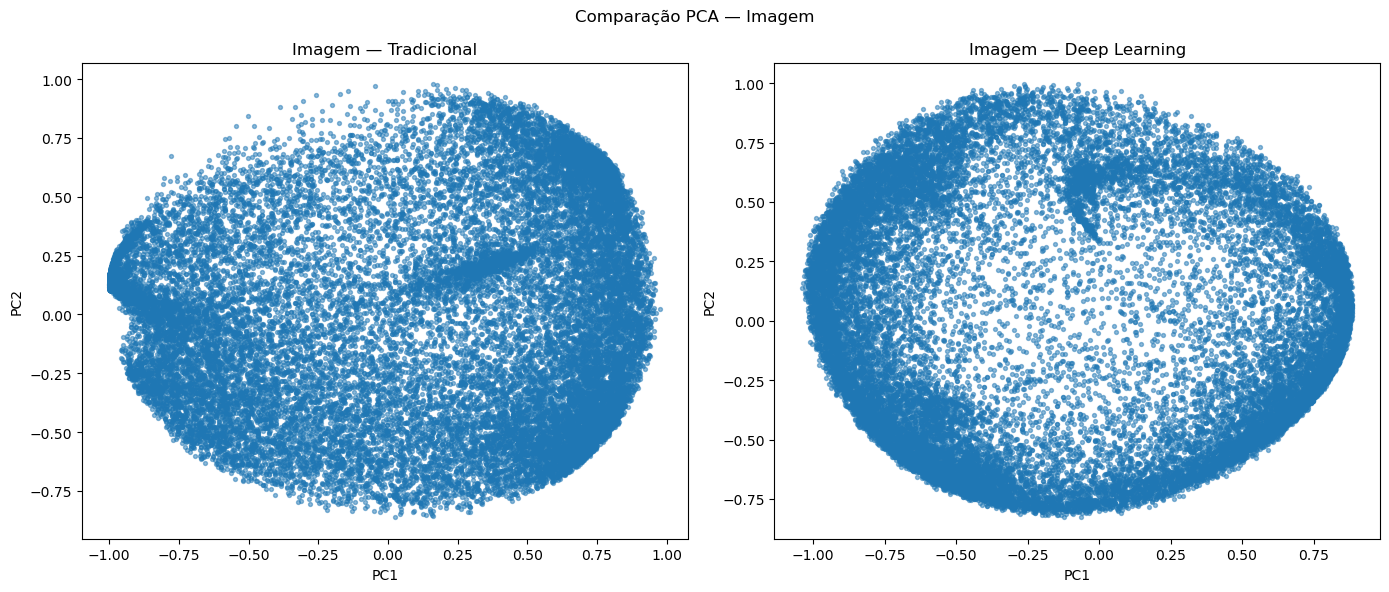


Imagem
Variância explicada PCA tradicional: 0.60616946
Variância explicada PCA DL: 0.6598891

SIMILARIDADE — Texto
Spearman rho: 0.5666
p-value: 0.000000e+00

SIMILARIDADE — Imagem
Spearman rho: 0.8977
p-value: 0.000000e+00

Resultados salvos em:
/home/ettore/Documentos/PUC/Projeto_Deep_Learning/artefatos/Resultados_Comparacao


In [3]:

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity

from scipy.stats import spearmanr


# ============================================================
# 1. CONFIGURAÇÃO
# ============================================================

BASE_DIR = Path(
    "/home/ettore/Documentos/PUC/Projeto_Deep_Learning"
)

OUTPUT_DIR = BASE_DIR / "artefatos" / "Resultados_Comparacao"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42


# ============================================================
# 2. VALIDAR EMBEDDINGS
# ============================================================

def validar_embeddings(X, nome):

    X = np.asarray(X, dtype=np.float32)

    assert X.ndim == 2, (
        f"{nome} não possui 2 dimensões."
    )

    assert X.shape[1] == 128, (
        f"{nome} não possui 128 dimensões."
    )

    assert np.isfinite(X).all(), (
        f"{nome} possui valores NaN ou infinitos."
    )

    print(f"{nome}: {X.shape}")

    return X


X_Tradicional_Texto = validar_embeddings(
    X_Tradicional_Texto,
    "Texto Tradicional"
)

X_DL_Texto = validar_embeddings(
    X_DL_Texto,
    "Texto DL"
)

X_Tradicional_Imagem = validar_embeddings(
    X_Tradicional_Imagem,
    "Imagem Tradicional"
)

X_DL_Imagem = validar_embeddings(
    X_DL_Imagem,
    "Imagem DL"
)


# ============================================================
# 3. NORMALIZAÇÃO
# ============================================================

# Normalização L2.
# Útil para comparar direções dos vetores.

X_Tradicional_Texto_N = normalize(
    X_Tradicional_Texto
)

X_DL_Texto_N = normalize(
    X_DL_Texto
)

X_Tradicional_Imagem_N = normalize(
    X_Tradicional_Imagem
)

X_DL_Imagem_N = normalize(
    X_DL_Imagem
)


# ============================================================
# 4. FUNÇÃO PCA 2D
# ============================================================

def comparar_pca(
    X_trad,
    X_dl,
    modalidade
):

    pca_trad = PCA(n_components=2)

    pca_dl = PCA(n_components=2)

    Z_trad = pca_trad.fit_transform(X_trad)

    Z_dl = pca_dl.fit_transform(X_dl)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 6)
    )

    # Tradicional
    axes[0].scatter(
        Z_trad[:, 0],
        Z_trad[:, 1],
        s=8,
        alpha=0.5
    )

    axes[0].set_title(
        f"{modalidade} — Tradicional"
    )

    axes[0].set_xlabel("PC1")
    axes[0].set_ylabel("PC2")

    # DL
    axes[1].scatter(
        Z_dl[:, 0],
        Z_dl[:, 1],
        s=8,
        alpha=0.5
    )

    axes[1].set_title(
        f"{modalidade} — Deep Learning"
    )

    axes[1].set_xlabel("PC1")
    axes[1].set_ylabel("PC2")

    fig.suptitle(
        f"Comparação PCA — {modalidade}"
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / f"pca_{modalidade.lower()}.png",
        dpi=300
    )

    plt.show()

    plt.close()

    print(
        f"\n{modalidade}"
    )

    print(
        "Variância explicada PCA tradicional:",
        pca_trad.explained_variance_ratio_.sum()
    )

    print(
        "Variância explicada PCA DL:",
        pca_dl.explained_variance_ratio_.sum()
    )

    return Z_trad, Z_dl


# ============================================================
# 5. PCA — TEXTO
# ============================================================

Z_Texto_Tradicional, Z_Texto_DL = comparar_pca(
    X_Tradicional_Texto_N,
    X_DL_Texto_N,
    "Texto"
)


# ============================================================
# 6. PCA — IMAGEM
# ============================================================

Z_Imagem_Tradicional, Z_Imagem_DL = comparar_pca(
    X_Tradicional_Imagem_N,
    X_DL_Imagem_N,
    "Imagem"
)


# ============================================================
# 7. FUNÇÃO DE SIMILARIDADE
# ============================================================

def comparar_similaridade(
    X_trad,
    X_dl,
    modalidade,
    max_samples=3000
):

    rng = np.random.default_rng(
        RANDOM_STATE
    )

    n = len(X_trad)

    indices = rng.choice(
        n,
        size=min(n, max_samples),
        replace=False
    )

    X_trad_sample = X_trad[indices]

    X_dl_sample = X_dl[indices]

    sim_trad = cosine_similarity(
        X_trad_sample
    )

    sim_dl = cosine_similarity(
        X_dl_sample
    )

    mask = np.triu_indices_from(
        sim_trad,
        k=1
    )

    corr, p_value = spearmanr(
        sim_trad[mask],
        sim_dl[mask]
    )

    print("\n" + "=" * 60)
    print(f"SIMILARIDADE — {modalidade}")
    print("=" * 60)

    print(f"Spearman rho: {corr:.4f}")
    print(f"p-value: {p_value:.6e}")

    return {
        "modalidade": modalidade,
        "spearman_rho": corr,
        "p_value": p_value
    }


# ============================================================
# 8. SIMILARIDADE — TEXTO
# ============================================================

resultado_sim_texto = comparar_similaridade(
    X_Tradicional_Texto_N,
    X_DL_Texto_N,
    "Texto"
)


# ============================================================
# 9. SIMILARIDADE — IMAGEM
# ============================================================

resultado_sim_imagem = comparar_similaridade(
    X_Tradicional_Imagem_N,
    X_DL_Imagem_N,
    "Imagem"
)


# ============================================================
# 10. SALVAR RESULTADOS
# ============================================================

df_similaridade = pd.DataFrame([
    resultado_sim_texto,
    resultado_sim_imagem
])

df_similaridade.to_csv(
    OUTPUT_DIR / "similaridade.csv",
    index=False
)

print("\nResultados salvos em:")
print(OUTPUT_DIR)